# 🛒 Retail Sales — Exploratory Data Analysis

**Author:** Rushikesh &nbsp;|&nbsp; **B.Tech Data Science** &nbsp;|&nbsp; **Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## 🎯 Problem Statement

A retail company operates across **four U.S. regions** and sells through **three channels** — Wholesale, Distributor, and Export.
This analysis explores **64,104 transactions from January 2014 to February 2018** to answer the following business questions:

1. Are there **seasonal patterns** in revenue that can guide inventory and promotions?
2. Which **products and customers** drive the most — and least — value?
3. Does a **higher unit price** actually lead to a higher profit margin?
4. Which **regions and channels** represent the biggest risk or opportunity?

**Dataset:** 6-table Excel workbook · 64,104 transactions · 175 customers · 30 products

---
## 1. Setup & Data Loading

We start by importing all required libraries and loading each sheet from the Excel workbook into a separate dataframe.
The dataset is split across **6 tables** — each representing a different business entity that we will later join together.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all sheets from the Excel file into a dictionary of dataframes
# sheet_name=None loads every sheet at once
sheets = pd.read_excel('Regional Sales Dataset.xlsx',sheet_name=None)

In [3]:
df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_products=sheets['Products']
df_regions=sheets['Regions']
df_state_reg=sheets['State Regions']
df_budgets=sheets['2017 Budgets']

print("df_sales : ", df_sales.shape)
print("df_customers : ", df_customers.shape)
print("df_products : ", df_products.shape)
print("df_regions : ", df_regions.shape)
print("df_state_reg : ", df_state_reg.shape)
print("df_budgets : ", df_budgets.shape)

df_sales :  (64104, 12)
df_customers :  (175, 2)
df_products :  (30, 2)
df_regions :  (994, 15)
df_state_reg :  (49, 3)
df_budgets :  (30, 2)


**Preview each table** to understand its structure before merging.

In [4]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [5]:
df_customers .head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [6]:
df_products.head() 

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [7]:
df_regions.head() 

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [8]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [9]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


---
## 2. Data Quality Check — Null Value Audit

Before merging, we check every table for missing values.
Any nulls found here could silently corrupt the joined dataset, so this step is essential before any analysis.

In [10]:
# The State Regions sheet has the actual column names stored in the first data row
# We promote row 0 to the header, then drop it from the data, and reset the index
df_state_reg= df_state_reg.rename(columns=df_state_reg.iloc[0]).drop(df_state_reg.index[0]).reset_index(drop=True)

In [11]:
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


**Null check for each table:**

In [12]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [13]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [14]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [15]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [16]:
df_state_reg.isnull().sum()

State Code    0
State         0
Region        0
dtype: int64

In [17]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

**Finding:** All six tables are complete with **zero missing values**.
We can proceed to merging without any imputation or data loss.

---
## 3. Data Wrangling — Merging 6 Tables into One

The tables are related through foreign keys (e.g. `Customer Name Index` links Sales to Customers).
We perform **sequential left joins** starting from Sales Orders so that all 64,104 transaction records are preserved.

A left join keeps every row from the left (Sales) table and brings in matching columns from the right table.

In [18]:
# Merge With Customers

df=df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index')

In [19]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


Merge in Products — brings product name, unit price, and cost:

In [20]:
# Merge With Products

df=df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index')

In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


Merge in Regions — brings state and delivery region info:

In [22]:
# Merge With Region

df=df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id')

In [23]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


Merge in State Regions — maps state codes to region names (West, South, etc.):

In [24]:
# Merge With State Region

df=df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code')

In [25]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [26]:
df.columns = df.columns.str.strip().str.lower()
df_budgets.columns = df_budgets.columns.str.strip().str.lower()

Merge in 2017 Budgets — brings product-level budget targets for 2017 only:

In [27]:
# Merge With Budgets

df = df.merge(
    df_budgets,
    how='left',
    on='product name'
)

In [28]:
df.head()

,ordernumber,orderdate,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order quantity,unit price,...,area_code,population,households,median_income,land_area,water_area,time_zone,state code,region,2017 budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


**Save a backup** of the merged dataframe before cleaning — useful for debugging:

In [29]:
df.to_csv('file.csv')

**Clean up** redundant join key columns that were created during the merges and are no longer needed:

In [30]:
#Customer Index
#Index
#id
#State Code

# Clean up redundant columns
cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df = df.drop(columns = cols_to_drop, errors='ignore')

df.head(5)

,ordernumber,orderdate,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order quantity,unit price,...,area_code,population,households,median_income,land_area,water_area,time_zone,state code,region,2017 budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


**Standardise column names** — strip whitespace, convert to lowercase for consistent access:

In [31]:
# Convert all the columns to lower case

df.columns = df.columns.str.strip().str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer index',
       'customer names', 'index', 'product name', 'name', 'county',
       'state_code', 'state', 'type', 'latitude', 'longitude',
       'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'state code', 'region',
       '2017 budgets'], dtype=object)

Remove any duplicate columns that may have been introduced by the joins:

In [32]:
# ================================
#  Remove duplicate columns
# ================================

df = df.loc[:, ~df.columns.duplicated()]


Rename columns to a clean `snake_case` format for easier coding:

In [33]:
# ================================
#  Rename columns to clean format
# ================================

df = df.rename(columns={
    'ordernumber': 'order_number',
    'orderdate': 'order_date',
    'customer names': 'customer_name',
    'product name': 'product_name',
    'order quantity': 'order_quantity',
    'unit price': 'unit_price',
    'line total': 'revenue',
    'total unit cost': 'cost',
    'state_code': 'state',
    'state': 'state_name',
    'latitude': 'lat',
    'longitude': 'lon',
    '2017 budgets': 'budget'
})

Convert `order_date` from string/object to a proper datetime type so we can extract month, year etc.:

In [34]:
# ================================
#  Convert order_date to datetime
# ================================

df['order_date'] = pd.to_datetime(df['order_date'])

Budget data was only provided for 2017.
We blank out the budget column for all other years so it doesn't mislead any budget vs actual comparisons:

In [35]:
# ================================
#  Blank out budgets for non-2017 orders
# ================================

df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

In [36]:
# ================================
#  Check the result
# ================================

df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [37]:
df[['order_date','product_name','revenue','budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


Final structure of the merged dataframe:

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_number               64104 non-null  object        
 1   order_date                 64104 non-null  datetime64[ns]
 2   customer name index        64104 non-null  int64         
 3   channel                    64104 non-null  object        
 4   currency code              64104 non-null  object        
 5   warehouse code             64104 non-null  object        
 6   delivery region index      64104 non-null  int64         
 7   product description index  64104 non-null  int64         
 8   order_quantity             64104 non-null  int64         
 9   unit_price                 64104 non-null  float64       
 10  revenue                    64104 non-null  float64       
 11  cost                       64104 non-null  float64       
 12  cust

Create a 2017-only slice for budget vs actual analysis later:

In [39]:
# Filter the data set to have only records from 2017

df_2017=df[df["order_date"].dt.year==2017]

In [40]:
df_2017.isnull().sum()

order_number                 0
order_date                   0
customer name index          0
channel                      0
currency code                0
warehouse code               0
delivery region index        0
product description index    0
order_quantity               0
unit_price                   0
revenue                      0
cost                         0
customer index               0
customer_name                0
index                        0
product_name                 0
name                         0
county                       0
state                        0
state_name                   0
type                         0
lat                          0
lon                          0
area_code                    0
population                   0
households                   0
median_income                0
land_area                    0
water_area                   0
time_zone                    0
state code                   0
region                       0
budget  

**Summary:** We now have a single flat table of **64,104 rows** with clean column names, correct data types, and all business dimensions (product, customer, region, channel, budget) joined in.

---
## 4. Feature Engineering

The raw data gives us `revenue`, `order_quantity`, and `cost` — but not profit.
We derive three new columns that are essential for profitability analysis:

| New Column | Formula | Why we need it |
|---|---|---|
| `total_cost` | `order_quantity × cost` | Actual cost of goods for that order line |
| `profit` | `revenue − total_cost` | How much money was made on each line |
| `profit_margin_pct` | `(profit / revenue) × 100` | Comparable % margin across products of different sizes |

In [41]:
df.head()

,order_number,order_date,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order_quantity,unit_price,...,area_code,population,households,median_income,land_area,water_area,time_zone,state code,region,budget
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,NaN
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,NaN
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,NaN
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,NaN
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,NaN


In [42]:
# Total cost = how many units were sold × cost per unit
df['total_cost']=df['order_quantity']*df['cost']

In [43]:
# Profit = what we earned (revenue) minus what it cost us to fulfil the order
df['profit']=df['revenue']-df['total_cost']

In [44]:
# Profit margin % = what proportion of each sale is actual profit
# Expressed as a percentage so we can compare across products fairly
df['profit_margin_pct']= df['profit'] / df['revenue'] * 100

In [45]:
df.head()

,order_number,order_date,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order_quantity,unit_price,...,median_income,land_area,water_area,time_zone,state code,region,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,36466,268318796,13908113,America/New York,GA,South,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,124759,62489257,386195,America/Los Angeles,CA,West,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,63158,70972793,720300,America/New York,CT,Northeast,NaN,10082.160,8249.040,45.0


---
## 5. Exploratory Data Analysis

With a clean, feature-rich dataset we now explore five business questions through visualisation:

| # | Question |
|---|----------|
| Q1 | Does revenue follow a seasonal pattern across the year? |
| Q2 | Which sales channel dominates — and what risk does that create? |
| Q3 | Which products generate the most revenue vs the best margins? |
| Q4 | Which regions lead and which are underperforming? |
| Q5 | Is the customer base concentrated in a few high-value accounts? |

### Q1 — Does revenue follow a seasonal pattern?

**What we're looking for:** Consistent peaks or troughs at the same time each year would confirm seasonality.
If the pattern repeats, it means we can **predict demand cycles** and plan inventory and promotions accordingly.

We group revenue by calendar month and plot the full time series.

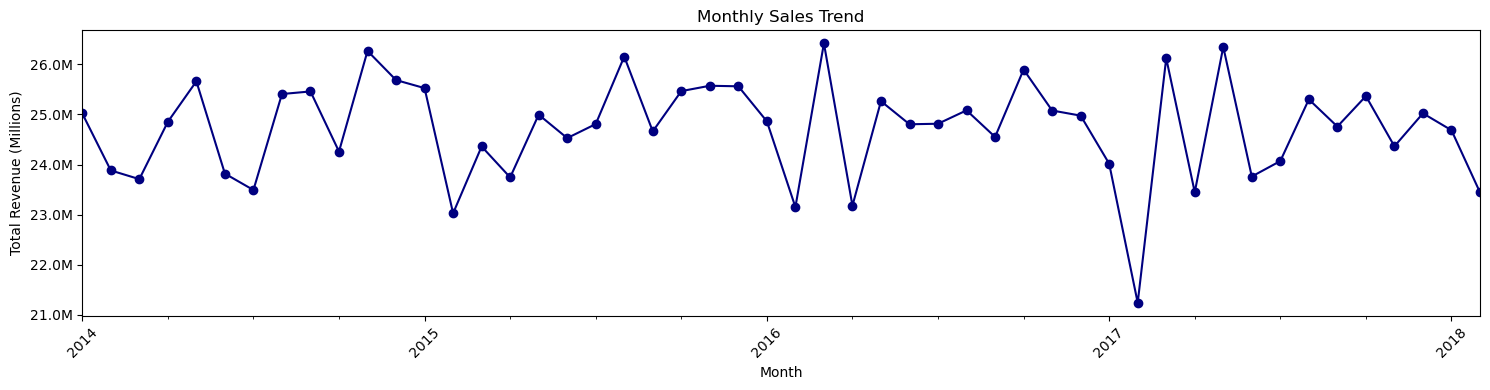

In [46]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02)
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Set figure size for clarity
plt.figure(figsize=(15,4))

# Plot the monthly sales trend with circle markers and navy line
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

**Insight:** Revenue follows a clear and **repeating bi-modal seasonal pattern** across all four years.

- A **primary peak appears May–August** — likely driven by mid-year buying cycles
- A **secondary uplift in November–December** aligns with holiday/year-end demand
- **January–February are the weakest months** every year without exception

→ **Action:** Stock up inventory before May. Use January–February for off-season promotions or lean operations.

### Q2 — Which sales channel generates the most revenue?

**What we're looking for:** How revenue is split between Wholesale, Distributor, and Export.
Heavy concentration in one channel is a business risk — if that channel struggles, overall revenue drops sharply.

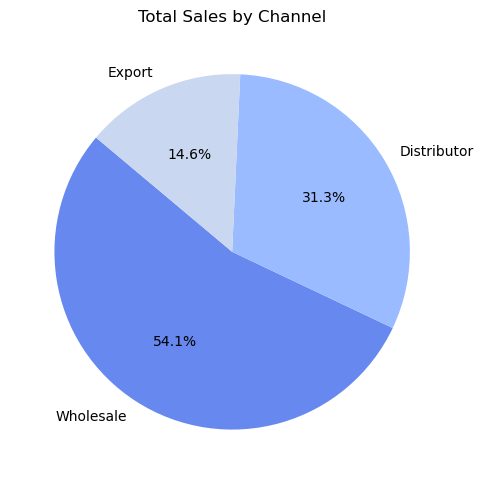

In [47]:
# Group revenue by sales channel and sort descending
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

# Set figure size for the pie chart
plt.figure(figsize=(5, 5))

# Plot pie chart with percentage labels and a defined start angle
plt.pie(
    chan_sales.values,                   # Data: revenue values per channel
    labels=chan_sales.index,             # Labels: channel names
    autopct='%1.1f%%',                   # Display percentages with one decimal
    startangle=140,                      # Rotate chart so first slice starts at 140 degrees
    colors=sns.color_palette('coolwarm') # Color palette for slices
)

# Add title for context
plt.title('Total Sales by Channel')

# Adjust layout to ensure everything fits well
plt.tight_layout()

# Display the chart
plt.show()

**Insight:** **Wholesale dominates at ~54% of revenue**, with Distributor at ~31% and Export at ~15%.

- This is a classic case of **channel concentration risk** — over half the business depends on one route to market
- Export is the smallest channel but represents the most potential for international growth

→ **Action:** Invest in growing Distributor and Export channels to reduce dependency on Wholesale.

### Q3 — Which products drive revenue — and do the same products lead on margin?

**What we're looking for:** Whether the top revenue products are also the most profitable.
In many businesses these lists are different — a product can be a best-seller but have thin margins due to high costs.

**Top 10 products by total revenue:**

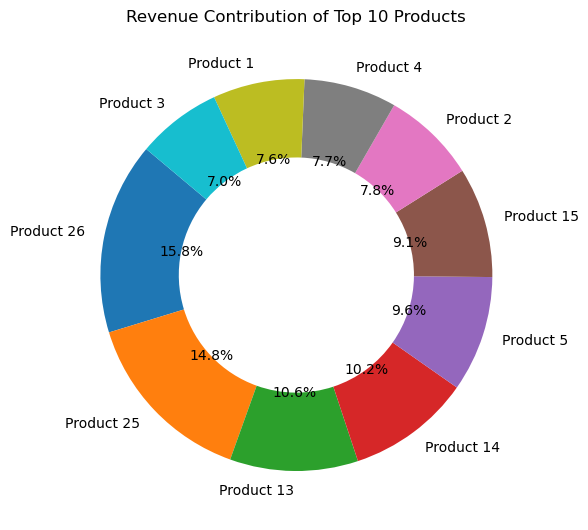

In [48]:
# Calculate product revenue
prod_rev = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=False)
)

# Take top 10 products
top10 = prod_rev.head(10)

# Convert to millions
top10_m = top10 / 1e6

plt.figure(figsize=(6,6))

plt.pie(
    top10_m.values,
    labels=top10_m.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)   # donut effect
)

plt.title('Revenue Contribution of Top 10 Products')

plt.tight_layout()
plt.show()

**Top 10 products by average profit margin:**

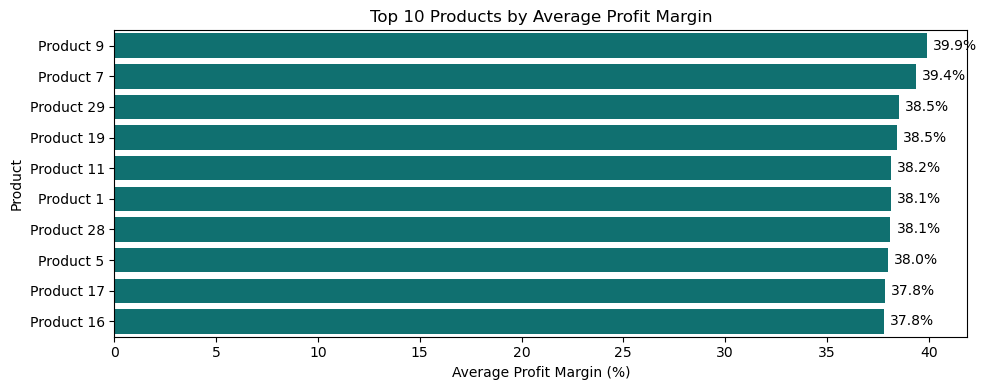

In [49]:
# Calculate average profit margin for each product
top_margin = (
    df.groupby('product_name')['profit_margin_pct']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,4))

ax = sns.barplot(
    x=top_margin.values,
    y=top_margin.index,
    color='teal'
)

# Add value labels
for i, v in enumerate(top_margin.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va='center')

plt.title('Top 10 Products by Average Profit Margin')
plt.xlabel('Average Profit Margin (%)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

**Insight:** The top revenue products and top margin products are **not the same list**.

- Product 26 and Product 25 lead on revenue but don't necessarily top the margin chart
- Some mid-tier revenue products deliver **significantly better margins**
- This means **pricing alone does not drive profitability** — cost management matters more

→ **Action:** Audit the cost structure of high-volume, low-margin products. Promote mid-tier products with strong margins.

### Q4 — How is revenue distributed across U.S. regions?

**What we're looking for:** Whether revenue is evenly distributed or concentrated in certain regions.
Large gaps between regions indicate either market strength differences or **underinvestment in weaker regions**.

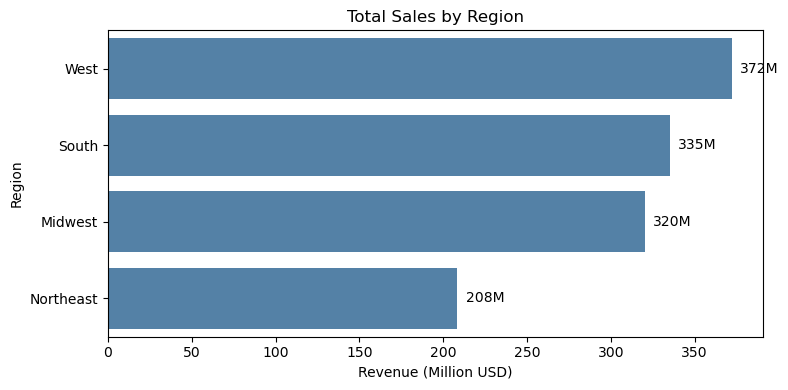

In [50]:
# Aggregate revenue by region
region_sales = (
    df.groupby('region')['revenue']
      .sum()
      .sort_values(ascending=False) / 1e6
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    color='steelblue'
)

# Add labels on bars
for i, v in enumerate(region_sales.values):
    ax.text(v + 5, i, f"{v:.0f}M", va='center')

plt.title('Total Sales by Region')
plt.xlabel('Revenue (Million USD)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

**Insight:** The **West leads in total revenue**, followed by the South. Midwest and Northeast lag significantly behind.

- The West and South together account for the majority of revenue
- Midwest and Northeast are not low-demand regions — they are **underserved markets**

→ **Action:** Assess whether the Midwest and Northeast need more sales reps, distributor partnerships, or marketing investment.

### Q5 — Is revenue concentrated among a small number of customers?

**What we're looking for:** The Pareto (80/20) effect — where a small number of customers generate a disproportionate share of revenue.
We look at order frequency (how often a customer buys) vs average order value (how much they spend per order).

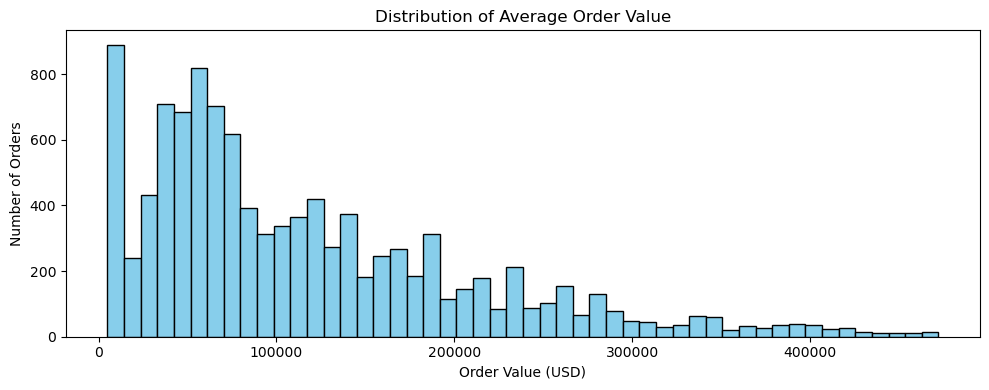

In [51]:
# Calculate order value per order
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(10,4))

plt.hist(
    aov,
    bins=50,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Insight:** Order values are **right-skewed** — most orders are small, but a tail of high-value orders pulls the average up.
This confirms a Pareto-like concentration: a small cohort of high-frequency, high-value customers drives the bulk of revenue.

- **175 total customers** across 4 years, but not all are equal in value
- Losing even 2–3 top accounts could meaningfully impact total revenue

→ **Action:** Identify and protect top accounts with dedicated account management. Target mid-tier customers to broaden the base.

---
## 6. Summary of Key Findings

| # | Business Question | Finding | Recommended Action |
|---|---|---|---|
| Q1 | Seasonal patterns? | Peaks May–Aug and Nov–Dec; troughs Jan–Feb | Align inventory & promos with demand cycles |
| Q2 | Channel concentration? | Wholesale ~54% — dominant but risky | Grow Distributor & Export channels |
| Q3 | Revenue vs margin leaders? | Top revenue ≠ top margin products | Audit costs on high-volume SKUs |
| Q4 | Regional gaps? | West & South lead; Midwest & NE lag | Invest in underperforming regions |
| Q5 | Customer concentration? | Small cohort drives most revenue | Retention for top accounts + mid-tier acquisition |

---

## 7. Next Steps

- [ ] **Time-Series Forecasting** — Use ARIMA or Prophet to predict monthly revenue
- [ ] **Customer Segmentation** — RFM analysis + K-Means clustering to group customers by value
- [ ] **Budget vs Actual Analysis** — Compare 2017 product performance against budget targets
- [x] **Power BI Dashboard** — Interactive version of these charts *(in progress)*